<a href="https://colab.research.google.com/github/Anthony253400/Projet_SDD_4/blob/main/Premiers_modele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!git clone https://github.com/Anthony253400/Projet_SDD_4

Cloning into 'Projet_SDD_4'...
remote: Enumerating objects: 2829, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 2829 (delta 16), reused 29 (delta 9), pack-reused 2793 (from 2)
Receiving objects: 100% (2829/2829), 73.68 MiB | 21.25 MiB/s, done.
Resolving deltas: 100% (132/132), done.
Updating files: 100% (7631/7631), done.


In [6]:
#lib
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os


from tensorflow import keras
from tensorflow.keras.models import Model
import tensorflow as tf

seed = 25
tf.keras.utils.set_random_seed(seed)

In [7]:


base_path = f'/content/Projet_SDD_4/data'
img_height= 384
img_width = 512
batch_size = 32


train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/Projet_SDD_4/data/train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed = seed

)

val_data = tf.keras.utils.image_dataset_from_directory(
   '/content/Projet_SDD_4/data/val',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = val_data.class_names
print(class_names)
print(train_data.class_names)


Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


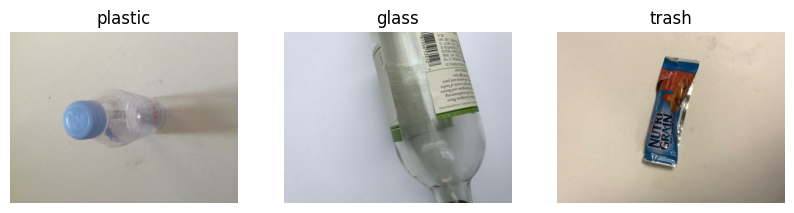

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

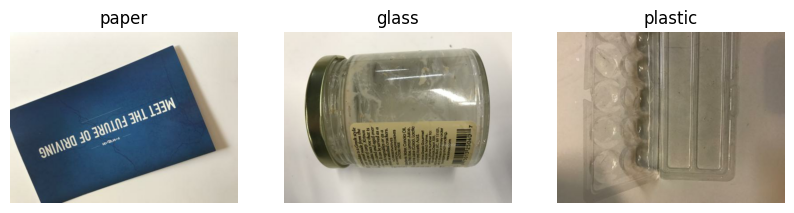

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in val_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [12]:
num_classes = 6

model1 = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model1.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy'],)

callback_modele1 = tf.keras.callbacks.TensorBoard(log_dir="logs/model1")

model1.fit(
    train_data,
  validation_data=val_data,
  epochs=8,
    callbacks=[callback_modele1]
)

Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 749ms/step - accuracy: 0.2129 - loss: 1.7482 - val_accuracy: 0.2390 - val_loss: 1.6744
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 54s 686ms/step - accuracy: 0.2906 - loss: 1.6768 - val_accuracy: 0.3087 - val_loss: 1.5995
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.3641 - loss: 1.5296

KeyboardInterrupt: 

In [11]:
num_classes = 6

model2 = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model2.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy'],)

logdir="logs"

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
model2.fit(
    train_data,
  validation_data=val_data,
  epochs=8,
    callbacks=[tensorboard_callback]
)

Epoch 1/8


KeyboardInterrupt: 

In [3]:
model1.summary()

NameError: name 'model' is not defined

In [10]:
test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/Projet_SDD_4/data/test',
    image_size=(img_height, img_width),
    batch_size=batch_size
)
print("Modele 1 :")
results = model1.evaluate(test_data)
print(f"Perte sur le test : {results[0]:.4f}")
print(f"Précision sur le test : {results[1]*100:.2f}%")

print("Modele 2 :")
results = model2.evaluate(test_data)
print(f"Perte sur le test : {results[0]:.4f}")
print(f"Précision sur le test : {results[1]*100:.2f}%")

Found 2527 files belonging to 6 classes.
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.7958 - loss: 0.5846
Perte sur le test : 0.5935
Précision sur le test : 79.30%


In [ ]:
model1.save('cnn1.keras')
model2.save('cnn2.keras')